<a href="https://colab.research.google.com/github/mikysetiawan/MachineLearningExpert/blob/master/Tugas_Akhir_Timeseries_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import statsmodels.api as sm

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url, parse_dates=['Date'], index_col='Date')

df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53150 entries, 2017-09-21 09:00:00.000 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8+ MB


Checking null value

In [4]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Close,0
Volume USDT,0
RSI,0
MACD_Hist,0
ATR,0
KAMAO,0


Trying rolling mean to denoised data

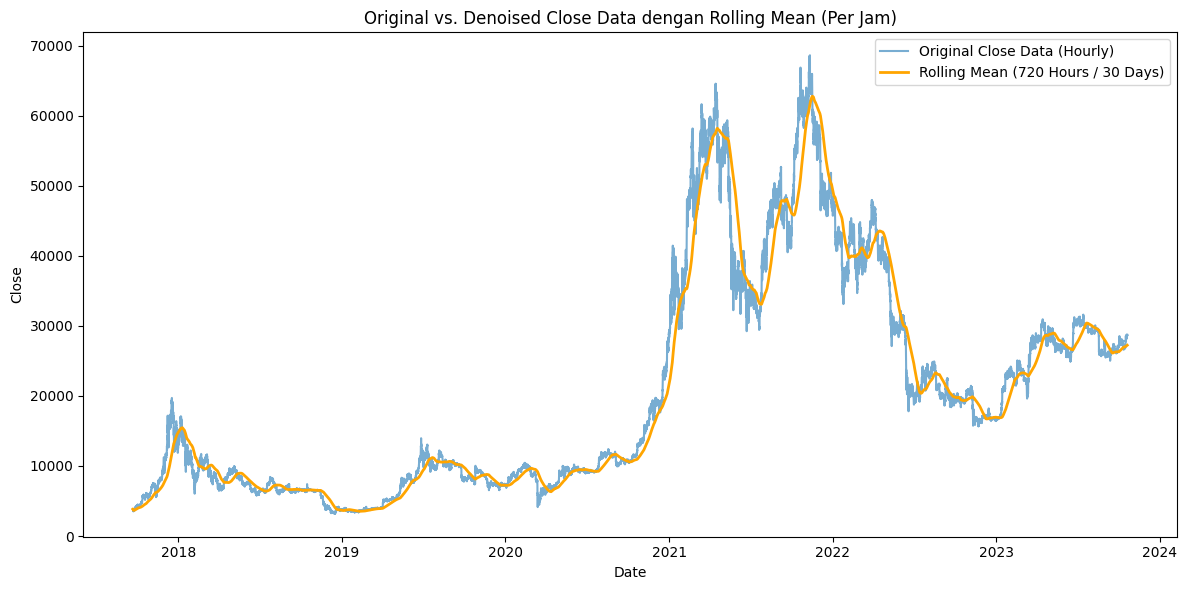

In [5]:
# Change index datatype to datetime
df.index = pd.to_datetime(df.index, format='mixed')

# copy dataset
df_hourly = df.copy()

# Run rolling mean with window 1 month
# 30 day * 24 hours = 720 hours.
df_hourly['Rolling_Mean'] = df_hourly['Close'].rolling(window=720, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_hourly.index, df_hourly['Close'], label='Original Close Data (Hourly)', alpha=0.6)
plt.plot(df_hourly.index, df_hourly['Rolling_Mean'], label='Rolling Mean (720 Hours / 30 Days)', color='orange', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Denoised Close Data dengan Rolling Mean (Per Jam)')
plt.legend()
plt.tight_layout()
plt.show()

# ========== EDA =============

Seasonal and Trend decomposition using Loess

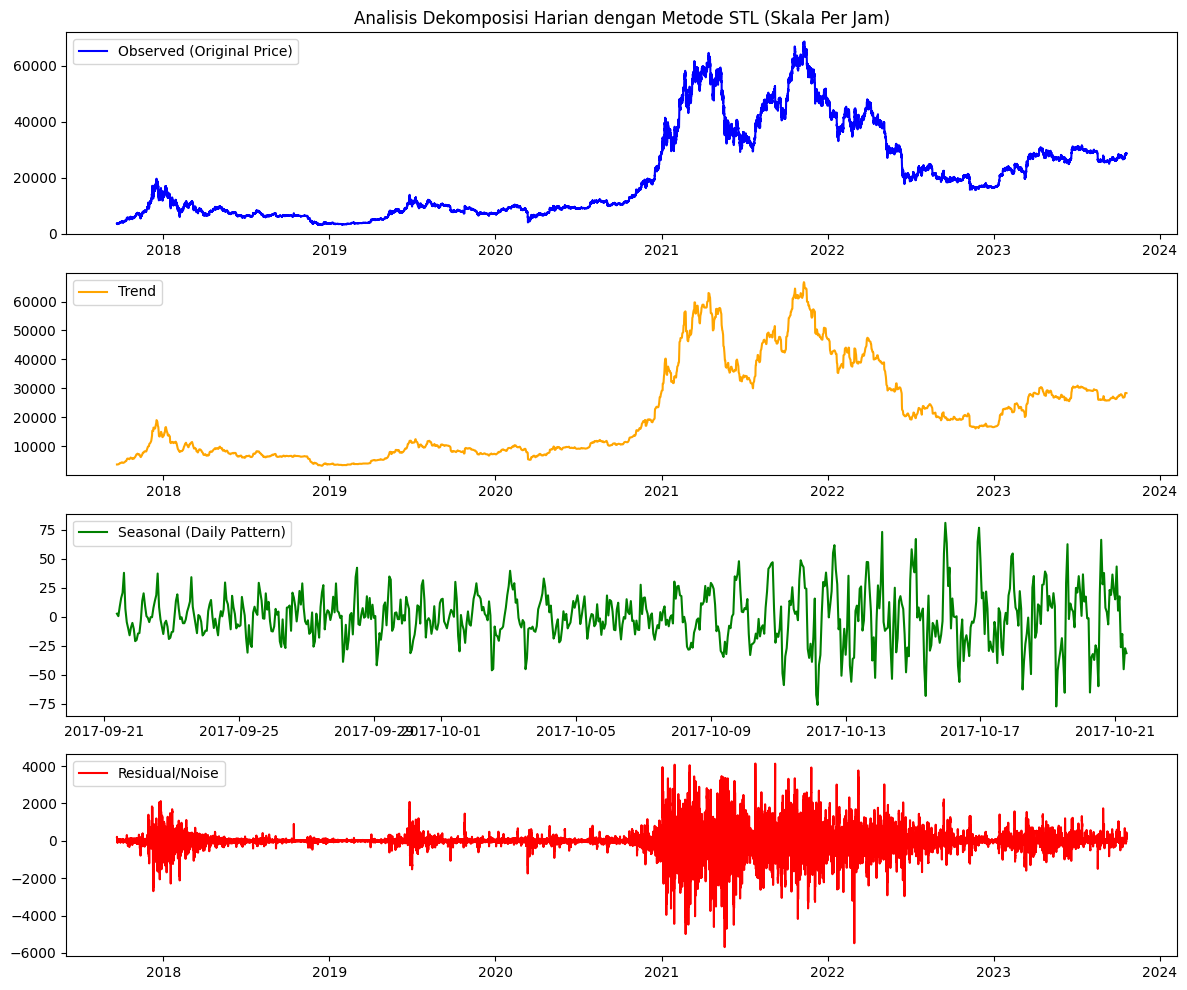

In [6]:
# Calculate decomposition from Close
stl = STL(df_hourly['Close'], period=24, robust=True)
decomposition = stl.fit()

plt.figure(figsize=(12, 10))

# 1. Observed
plt.subplot(411)
plt.plot(df_hourly.index, decomposition.observed, label='Observed (Original Price)', color='blue')
plt.legend(loc='upper left')
plt.title('Analisis Dekomposisi Harian dengan Metode STL (Skala Per Jam)')

# 2. Trend
plt.subplot(412)
plt.plot(df_hourly.index, decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

# 3. Seasonal (Menampilkan grafik 1 bulan pertama = 720 jam untuk melihat polanya)
plt.subplot(413)
plt.plot(df_hourly.index[:720], decomposition.seasonal[:720], label='Seasonal (Daily Pattern)', color='green')
plt.legend(loc='upper left')

# 4. Residual
plt.subplot(414)
plt.plot(df_hourly.index, decomposition.resid, label='Residual/Noise', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Check stationary data with ADF

In [7]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df_hourly['Close'])

ADF Test Results:
ADF Statistic: -1.5594011394616105
p-value: 0.5039489237257468
Data tidak stasioner


In [8]:
print("===== adf test Volume USDT ==========")
adf_test(df_hourly['Volume USDT'])
print("===== adf test RSI ==========")
adf_test(df_hourly['RSI'])
print("===== adf test MACD_Hist ==========")
adf_test(df_hourly['MACD_Hist'])
print("===== adf test ATR ==========")
adf_test(df_hourly['ATR'])
print("===== adf test KAMAO ==========")
adf_test(df_hourly['KAMAO'])

===== adf test Volume USDT ==========
ADF Test Results:
ADF Statistic: -8.370741375695141
p-value: 2.6665450890014613e-13
Data stasioner
===== adf test RSI ==========
ADF Test Results:
ADF Statistic: -8.23940675812908
p-value: 5.771375320348243e-13
Data stasioner
===== adf test MACD_Hist ==========
ADF Test Results:
ADF Statistic: -13.057517328088691
p-value: 2.0799966877462827e-24
Data stasioner
===== adf test ATR ==========
ADF Test Results:
ADF Statistic: -1.8613754244450191
p-value: 0.3504436609247079
Data tidak stasioner
===== adf test KAMAO ==========
ADF Test Results:
ADF Statistic: -14.416472567986332
p-value: 8.043618591043793e-27
Data stasioner


TODO: DELETE = TRYING DAILY DATA

In [9]:
# # Buat DataFrame baru khusus untuk fitur model forecasting
# df_features = pd.DataFrame(index=df_daily.index)

# # 1. Transformasi target harga (gunakan Close atau Rolling Mean Anda)
# # Diubah menjadi persentase return harian agar stasioner sempurna
# df_features['Close'] = df_daily['Close'].diff()

# # 2. Transformasi Volume USDT (Gunakan diff karena tidak stasioner)
# df_features['Volume USDT'] = df_daily['Volume USDT'].diff()

# # 3. Transformasi ATR (Gunakan Log + Diff karena varians tidak konstan)
# df_features['ATR'] = np.log(df_daily['ATR']).diff()

# # 4. Kolom yang sudah lolos (Stasioner) langsung dimasukkan tanpa diubah
# df_features['RSI'] = df_daily['RSI']
# df_features['MACD_Hist'] = df_daily['MACD_Hist']
# df_features['KAMAO'] = df_daily['KAMAO']

# # Wajib gunakan .dropna() karena efek .diff() dan .pct_change() menyisakan nilai kosong di baris paling awal
# df_features.dropna(inplace=True)

# # ---- PEMBUKTIAN ----
# # Mari kita uji ulang apakah DataFrame baru ini sudah 100% stasioner semuanya
# print("=== VERIFIKASI AKHIR DATASET STASIONER ===")
# for col in df_features.columns:
#     print(f"\n===== adf test {col} =====")
#     adf_test(df_features[col])


ACF & PACF

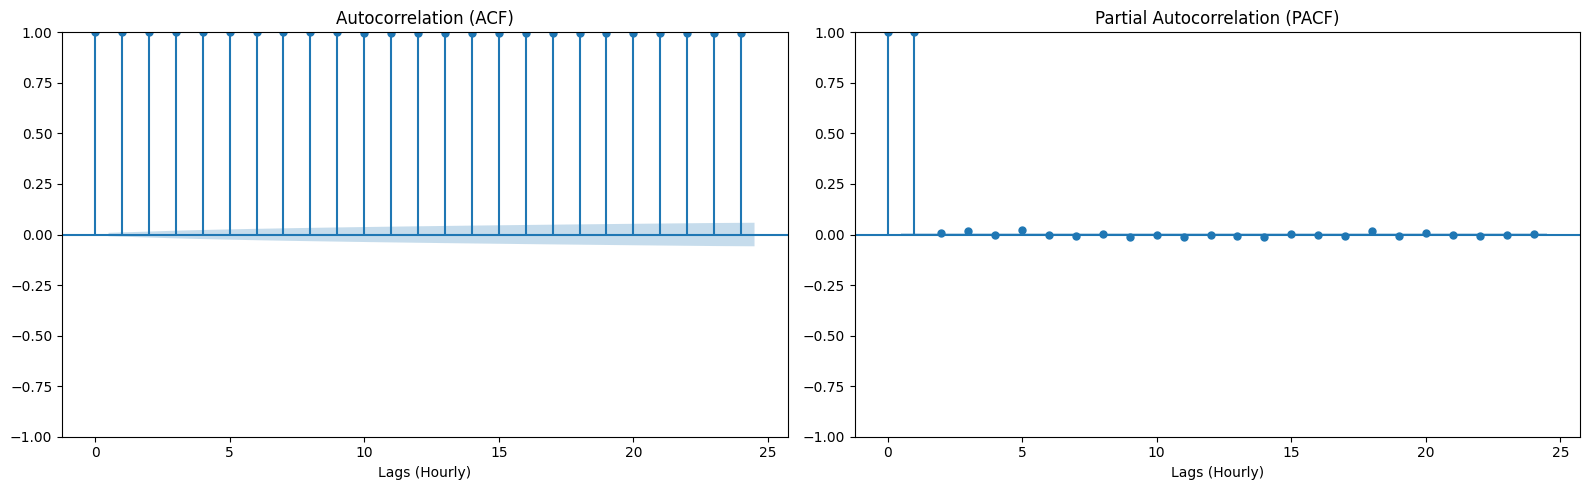

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(df_hourly['Close'], lags=24, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lags (Hourly)')

# Plot Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(df_hourly['Close'], lags=24, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lags (Hourly)')

plt.tight_layout()
plt.show()

Creating DataFrame Features


In [11]:
df_features = pd.DataFrame(index=df_hourly.index)
df_features['Trend_STL'] = decomposition.trend
df_features['Seasonal_STL'] = decomposition.seasonal
df_features['Hour'] = df_features.index.hour
df_features['Close'] = df_hourly['Close']
df_features['Volume USDT'] = df_hourly['Volume USDT']
df_features['ATR'] = df_hourly['ATR']
df_features['RSI'] = df_hourly['RSI']
df_features['MACD_Hist'] = df_hourly['MACD_Hist']
df_features['KAMAO'] = df_hourly['KAMAO']

# ---- TESTING ----
# See if the data already stationer or not
print("=== VERIFICATION STATIONER DATASET  ===")
for col in df_features.columns:
    print(f"\n===== adf test {col} =====")
    adf_test(df_features[col])

=== VERIFICATION STATIONER DATASET  ===

===== adf test Trend_STL =====
ADF Test Results:
ADF Statistic: -1.486075255628424
p-value: 0.5403881211227265
Data tidak stasioner

===== adf test Seasonal_STL =====
ADF Test Results:
ADF Statistic: -56.4105760975827
p-value: 0.0
Data stasioner

===== adf test Hour =====
ADF Test Results:
ADF Statistic: -37.091484822796836
p-value: 0.0
Data stasioner

===== adf test Close =====
ADF Test Results:
ADF Statistic: -1.5594011394616105
p-value: 0.5039489237257468
Data tidak stasioner

===== adf test Volume USDT =====
ADF Test Results:
ADF Statistic: -8.370741375695141
p-value: 2.6665450890014613e-13
Data stasioner

===== adf test ATR =====
ADF Test Results:
ADF Statistic: -1.8613754244450191
p-value: 0.3504436609247079
Data tidak stasioner

===== adf test RSI =====
ADF Test Results:
ADF Statistic: -8.23940675812908
p-value: 5.771375320348243e-13
Data stasioner

===== adf test MACD_Hist =====
ADF Test Results:
ADF Statistic: -13.057517328088691
p-valu

Creating feature rolling standard deviation for each 24h

In [12]:
# Creating new feature volatility price based on Rolling Standard Deviation 24h
df_features['Close_Volatility_24h'] = df_features['Close'].rolling(window=24).std()

# Because rolling make the first data become NaN, fill it with bfill method
df_features['Close_Volatility_24h'] = df_features['Close_Volatility_24h'].bfill()

# Clean up data Nan
df_features.dropna(inplace=True)

print("List feature:")
print(df_features.head())

List feature:
                       Trend_STL  Seasonal_STL  Hour    Close    Volume USDT  \
Date                                                                           
2017-09-21 09:00:00  3657.721516      2.539107     9  3860.00   74434.891166   
2017-09-21 10:00:00  3657.101069      0.413535    10  3871.48   44687.318944   
2017-09-21 11:00:00  3656.466229      8.654769    11  3864.95   80546.171672   
2017-09-21 12:00:00  3655.816934     15.981174    12  3858.08   90331.531390   
2017-09-21 13:00:00  3655.152469     20.543084    13  3856.67  103405.818040   

                           ATR        RSI  MACD_Hist     KAMAO  \
Date                                                             
2017-09-21 09:00:00  88.054720  49.192454 -48.279697  2.495591   
2017-09-21 10:00:00  87.996283  49.233202 -47.780476  2.616710   
2017-09-21 11:00:00  87.897128  49.210685 -47.308061  2.532239   
2017-09-21 12:00:00  87.720856  49.186948 -46.863233  2.447245   
2017-09-21 13:00:00  87.57808

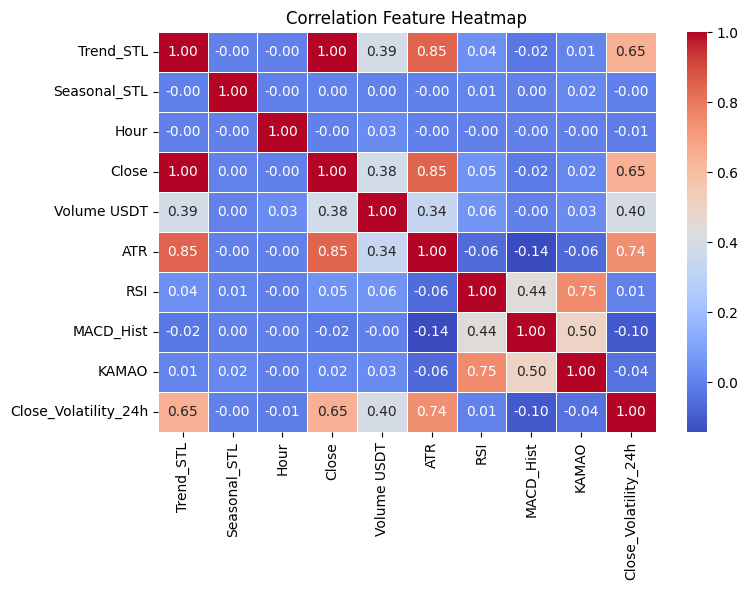

In [13]:
plt.figure(figsize=(8, 6))
# Calc correlation each feature
correlation_matrix = df_features.corr()

# Create Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Feature Heatmap')
plt.tight_layout()
plt.show()

# ========== Creating LSTM Model =============

In [14]:
# 1. Strictly separate Features (X) and Target (Y) in pandas before scaling
# Ensure the non-stationary raw 'Close' price is excluded from the input features
stationary_features = ['Trend_STL', 'Seasonal_STL', 'Hour', 'Close_Volatility_24h', 'Volume USDT', 'ATR', 'RSI', 'MACD_Hist', 'KAMAO']

X_df = df_features[stationary_features]
y_df = df_features[['Close']]  # The absolute target remains 'Close'

# 2. Split the data at the Pandas level first to completely prevent future data leakage
total_samples = len(df_features)
train_end = int(total_samples * 0.80)
val_end = int(total_samples * 0.90)

X_train_raw = X_df.iloc[:train_end]
X_val_raw   = X_df.iloc[train_end:val_end]
X_test_raw  = X_df.iloc[val_end:]

y_train_raw = y_df.iloc[:train_end]
y_val_raw   = y_df.iloc[train_end:val_end]
y_test_raw  = y_df.iloc[val_end:]

# 3. Initialize separate scalers for Features (X) and Target (y)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# FIT ONLY ON TRAINING DATA!
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_val_scaled   = scaler_X.transform(X_val_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled   = scaler_y.transform(y_val_raw)
y_test_scaled  = scaler_y.transform(y_test_raw)

# 4. Corrected sliding window function to build 3D NumPy arrays safely
def create_dataset_fixed(X_data, y_data, time_step=24):
    X, Y = [], []
    for i in range(len(X_data) - time_step):
        X.append(X_data[i:(i + time_step), :])
        Y.append(y_data[i + time_step, 0])  # Correctly extracts the scaled Close price at index 0
    return np.array(X), np.array(Y)

TIME_STEP = 24

# Construct independent 3D input windows and targets for each data subset
X_train_np, y_train_np = create_dataset_fixed(X_train_scaled, y_train_scaled, TIME_STEP)
X_val_np, y_val_np     = create_dataset_fixed(X_val_scaled, y_val_scaled, TIME_STEP)
X_test_np, y_test_np   = create_dataset_fixed(X_test_scaled, y_test_scaled, TIME_STEP)

# 5. Convert NumPy arrays into high-performance tf.data.Dataset pipelines
BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_np, y_train_np))
# Shuffle training data only to optimize model weights robustly
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_np, y_val_np)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_np, y_test_np)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Data PIPELINE successfully secured against leakages!")
print(f"X_train shape: {X_train_np.shape} -> Expected 3D shape: (samples, 24, num_features)")
print(f"y_train shape: {y_train_np.shape} -> Expected 1D shape: (samples,)")

Data PIPELINE successfully secured against leakages!
X_train shape: (42496, 24, 9) -> Expected 3D shape: (samples, 24, num_features)
y_train shape: (42496,) -> Expected 1D shape: (samples,)


In [15]:
# 1. Inisialisasi Model LSTM Dasar
model = Sequential([
    # Menggunakan Input layer eksplisit sesuai saran warning TensorFlow terbaru
    tf.keras.layers.Input(shape=(X_train_np.shape[1], X_train_np.shape[2])),
    LSTM(units=50, activation='tanh'),
    Dense(units=1)
])

# 2. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 3. Training Model Menggunakan tf.data.Dataset Pipeline
history = model.fit(
    train_dataset,
    validation_data=val_dataset, # Menggunakan data validation terpisah
    epochs=10,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,051 (47.07 KB)

 Trainable params: 12,051 (47.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2.6292e-04 - val_loss: 2.7584e-05
Epoch 2/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.8232e-05 - val_loss: 5.4706e-05
Epoch 3/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 6.0750e-05 - val_loss: 1.9175e-05
Epoch 4/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 6.2969e-05 - val_loss: 3.0570e-05
Epoch 5/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.7696e-05 - val_loss: 4.6426e-05
Epoch 6/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.9998e-05 - val_loss: 6.6488e-05
Epoch 7/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5.2506e-05 - val_loss: 2.3616e-05
Epoch 8/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 5.6203e-05 - val_loss: 3.5322e-05
Epoch 9/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.8113e-05 - val_loss: 1.6658e-05
Epoch 10/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5.1244e-05 - val_loss: 3.3952e-05


# ========== Custom Architecture Model ==========

In [16]:
def create_multistep_dataset(X_data, y_data, time_step=24, forecast_step=24):
    X, Y = [], []
    for i in range(len(X_data) - time_step - forecast_step + 1):
        X.append(X_data[i:(i + time_step), :])
        # Mengambil kolom 'Close' (indeks 0) untuk 24 langkah ke depan
        Y.append(y_data[(i + time_step):(i + time_step + forecast_step), 0])
    return np.array(X), np.array(Y)

FORECAST_STEP = 24
# Create dataset multi-step
X_train_ms, y_train_ms = create_multistep_dataset(X_train_scaled, y_train_scaled, time_step=TIME_STEP, forecast_step=FORECAST_STEP)
X_val_ms, y_val_ms     = create_multistep_dataset(X_val_scaled, y_val_scaled, time_step=TIME_STEP, forecast_step=FORECAST_STEP)
X_test_ms, y_test_ms   = create_multistep_dataset(X_test_scaled, y_test_scaled, time_step=TIME_STEP, forecast_step=FORECAST_STEP)

# Convert NumPy arrays into tf.data.Dataset pipelines
train_ds_ms = tf.data.Dataset.from_tensor_slices((X_train_ms, y_train_ms)).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds_ms   = tf.data.Dataset.from_tensor_slices((X_val_ms, y_val_ms)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds_ms  = tf.data.Dataset.from_tensor_slices((X_test_ms, y_test_ms)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("=== MULTI-STEP DIMENSIONS VERIFIED ===")
print(f"Multi-step Train Features Shape: {X_train_ms.shape} -> Expected: (samples, 24, 9)")
print(f"Multi-step Train Target Shape:   {y_train_ms.shape} -> Expected: (samples, 24)")

=== MULTI-STEP DIMENSIONS VERIFIED ===
Multi-step Train Features Shape: (42473, 24, 9) -> Expected: (samples, 24, 9)
Multi-step Train Target Shape:   (42473, 24) -> Expected: (samples, 24)


In [17]:
# ==============================================================================
# CUSTOMDENSE CLASS
# ==============================================================================
# A custom implementation of a fully-connected (Dense) layer.
# It performs a linear transformation on the input data: Y = (X * W) + B
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        # Initialize the parent Keras Layer class with standard parameters
        super(CustomDense, self).__init__(**kwargs)
        # Store the number of hidden units (neurons) for this layer
        self.units = units

    def build(self, input_shape):
        # Automatically triggered once when the layer receives its first input.
        # input_shape[-1] extracts the last dimension (feature size) of the incoming tensor.

        # Instantiate the Weight matrix (W)
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",  # Xavier initialization to stabilize early training gradients
            trainable=True,                # Explicitly marked so the optimizer can update it during backpropagation
            name="w"
        )
        # Instantiate the Bias vector (B), initialized to zeros for each output unit
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="b"
        )

    def call(self, inputs):
        # Core forward pass operation: Matrix multiplication of inputs and weights, plus bias
        return tf.matmul(inputs, self.w) + self.b


# ==============================================================================
# 2. CUSTOMMULTIHEADATTENTION CLASS
# ==============================================================================
# A custom implementation of the Multi-Head Attention mechanism (the core of Transformers).
# It maps queries, keys, and values to project sequential relationships across different subspaces.
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads  # Total number of parallel attention channels (heads)
        self.key_dim = key_dim      # Dimensionality of the feature space per head

    def build(self, input_shape):
        # Compute the combined dimensional space across all heads
        total_dim = self.num_heads * self.key_dim

        # Define custom linear projection layers for Query (Q), Key (K), and Value (V) matrices
        self.wq = CustomDense(total_dim)
        self.wk = CustomDense(total_dim)
        self.wv = CustomDense(total_dim)

        # Output dense layer to project the concatenated heads back to the original model dimension
        self.wo = CustomDense(input_shape[-1])

    def call(self, q, v, k=None):
        # Default to Self-Attention if an independent Key matrix is not explicitly provided
        if k is None:
            k = v

        # Step 1: Project the raw inputs into the designated attention feature space
        query = self.wq(q)
        key = self.wk(k)
        value = self.wv(v)

        # Step 2: Compute raw alignment scores using a dot-product multiplication
        # transpose_b=True flips the key matrix axes so that the inner dimensions align for multiplication
        scores = tf.matmul(query, key, transpose_b=True)

        # Step 3: Scale down the scores by the square root of the key dimension (Scaled Dot-Product)
        # This keeps score magnitudes manageable and prevents vanishing gradients during softmax activation
        scores = scores / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))

        # Step 4: Convert the scaled raw alignment scores into relative probability weights via Softmax
        # axis=-1 ensures the distribution normalizes cleanly across the sequence's rows
        weights = tf.nn.softmax(scores, axis=-1)

        # Step 5: Compute a weighted combination of the Value matrix based on the calculated weights
        output = tf.matmul(weights, value)

        # Step 6: Return the final output projected back into the expected input channel dimension
        return self.wo(output)


# ==============================================================================
# 3. CUSTOMLEAKYRELU CLASS
# ==============================================================================
# A custom non-linear activation layer implementing LeakyReLU.
# Unlike standard ReLU which maps negative entries to absolute 0, LeakyReLU allows
# a slight, scaled negative signal to prevent neurons from completely freezing.
class CustomLeakyRelu(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super(CustomLeakyRelu, self).__init__(**kwargs)
        self.alpha = alpha  # Linear scaling constant applied exclusively to negative signals

    def call(self, inputs):
        # Format: tf.where(condition, if_true, if_false)
        # If an input value is above zero, it passes through untouched (inputs).
        # If an input value is zero or below, it scales down mathematically (inputs * alpha).
        # This architectural tweak effectively mitigates the "Dying ReLU" network training problem.
        return tf.where(inputs > 0, inputs, inputs * self.alpha)


In [18]:
# --- Create Baseline with Built-in Attention & Custom Dense & Custom LeakyReLU ---
inputs = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]))
lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)

# Built-in MultiHeadAttention
mha_builtin = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32)(lstm_out, lstm_out)
lstm_flat = tf.keras.layers.Flatten()(mha_builtin)

dense_out = CustomDense(64)(lstm_flat)
act_out = CustomLeakyRelu()(dense_out)
outputs = CustomDense(FORECAST_STEP)(act_out)

model_baseline_builtin = tf.keras.Model(inputs, outputs, name="Baseline_LSTM_BuiltIn_MHA")
model_baseline_builtin.compile(optimizer='adam', loss='mse')
print("\n--- Training Baseline with Built-in MHA ---")
model_baseline_builtin.fit(train_ds_ms, validation_data=val_ds_ms, epochs=5, verbose=1)


# --- 2. Baseline with Custom Multi-Head Attention ---
inputs_c = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]))
lstm_out_c = tf.keras.layers.LSTM(64, return_sequences=True)(inputs_c)

# Use Custom MultiHeadAttention
mha_custom = CustomMultiHeadAttention(num_heads=2, key_dim=32)(lstm_out_c, lstm_out_c)
lstm_flat_c = tf.keras.layers.Flatten()(mha_custom)

dense_out_c = CustomDense(64)(lstm_flat_c)
act_out_c = CustomLeakyRelu()(dense_out_c)
outputs_c = CustomDense(FORECAST_STEP)(act_out_c)

model_baseline_custom = tf.keras.Model(inputs_c, outputs_c, name="Baseline_LSTM_Custom_MHA")
model_baseline_custom.compile(optimizer='adam', loss='mse')
print("\n--- Training Baseline with Custom MHA ---")
model_baseline_custom.fit(train_ds_ms, validation_data=val_ds_ms, epochs=5, verbose=1)


--- Training Baseline with Built-in MHA ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 4.7791e-04 - val_loss: 2.1728e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.1077e-04 - val_loss: 2.3411e-04
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.2713e-04 - val_loss: 1.2145e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.8933e-04 - val_loss: 1.3365e-04
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.0072e-04 - val_loss: 1.6603e-04

--- Training Baseline with Custom MHA ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5.2571e-04 - val_loss: 1.6773e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.2016e-04 - val_loss: 1.7077e-04
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.1929e-04 - val_loss: 2.1617e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.2628e-04 - val_loss: 1.6470e-04
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.8808e-04 - val

In [19]:
# Simpan model baseline LSTM setelah training selesai
model_baseline_custom.save("model_baseline_LSTM.keras")
print("Model Baseline berhasil disimpan sebagai model_baseline_LSTM.keras")

Model Baseline berhasil disimpan sebagai model_baseline_LSTM.keras


SEQ2SEQ

In [20]:
# 1. TEACHER FORCING PREPARATION (DATA MANIPULATION)

# Create a matrix of zeros with the exact same dimensions as your target training labels (y_train_ms)
dec_train_inputs = np.zeros_like(y_train_ms)
# Shift the target sequence to the right by 1 time step to create the target token inputs.
# The first element remains zero (acting as the Start-of-Sequence / <SOS> token indicator).
dec_train_inputs[:, 1:] = y_train_ms[:, :-1]
# Add a trailing dimension (axis=-1) to match the required 3D shape format: (batch_size, sequence_length, features)
dec_train_inputs = np.expand_dims(dec_train_inputs, axis=-1)

# Replicate the exact same right-shifting sequence logic for the validation dataset targets
dec_val_inputs = np.zeros_like(y_val_ms)
dec_val_inputs[:, 1:] = y_val_ms[:, :-1]
dec_val_inputs = np.expand_dims(dec_val_inputs, axis=-1)


# 2. TF.DATA PIPELINE INTEGRATION

# Package the training data into an optimized tf.data.Dataset pipeline.
# It pairs a nested tuple of inputs ((Encoder_X, Decoder_Teacher_Forcing_X), Target_Y)
train_s2s_ds = tf.data.Dataset.from_tensor_slices(((X_train_ms, dec_train_inputs), y_train_ms)).shuffle(1024).batch(BATCH_SIZE)

# Package the validation data similarly without a shuffle buffer to keep evaluation clean
val_s2s_ds = tf.data.Dataset.from_tensor_slices(((X_val_ms, dec_val_inputs), y_val_ms)).batch(BATCH_SIZE)



# 3. SEQ2SEQ ARCHITECTURE BUILDING (FUNCTIONAL API)

# --- ENCODER ---
# Define the structural input layer for the encoder tracking: (Sequence_Length, Feature_Dimensions)
encoder_inputs = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]), name="enc_input")
# Configure an LSTM layer that returns its entire temporal sequence and its internal structural hidden states
encoder_lstm = tf.keras.layers.LSTM(64, return_state=True, return_sequences=True)
# Pass inputs through the LSTM; capture the full hidden sequence (enc_outputs), final hidden state (state_h), and cell state (state_c)
enc_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
# Group the final hidden and cell states together to act as the raw context vectors for the decoder initialization
encoder_states = [state_h, state_c]

# --- DECODER ---
# Define the input layer for the decoder tracking: (Forecast_Steps, Feature_Dimension)
decoder_inputs = tf.keras.layers.Input(shape=(FORECAST_STEP, 1), name="dec_input")
# Configure the decoder LSTM to return its entire hidden sequence back for downstream cross-attention tracking
decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True)
# Run the decoder inputs while passing the encoder's internal hidden context states as its explicit starting weights
dec_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)


# 4. CUSTOM ATTENTION & OUTPUT LAYERS

# Apply your Custom Multi-Head Attention layer to execute cross-attention.
# Query = dec_outputs (decoder hidden states looking for specific contextual data)
# Value/Key = enc_outputs (encoder hidden states acting as the lookup reference database)
s2s_attention = CustomMultiHeadAttention(num_heads=2, key_dim=32)(dec_outputs, enc_outputs)

# Pass the contextual attention mappings into your custom Dense layer targeting 64 feature dimensions
s2s_dense = CustomDense(64)(s2s_attention)
# Pass the linear dense outputs through your custom LeakyReLU activation layer to avoid dying neural pathways
s2s_act = CustomLeakyRelu()(s2s_dense)
# Pass the non-linear outputs into a final custom Dense projection mapping down to a single value per time step
s2s_final = CustomDense(1)(s2s_act)

# Flatten or reshape the output tensor from 3D (batch_size, FORECAST_STEP, 1) to 2D (batch_size, FORECAST_STEP)
s2s_outputs = tf.keras.layers.Reshape((FORECAST_STEP,))(s2s_final)



# 5. MODEL COMPILATION & TRAINING EXECUTION

# Bind the structural inputs and downstream outputs cleanly inside a comprehensive Functional Keras Model object
model_s2s_functional = tf.keras.Model([encoder_inputs, decoder_inputs], s2s_outputs, name="Seq2Seq_Functional_TeacherForcing")
# Compile the network using the Adam optimizer engine and a standard Mean Squared Error loss configuration
model_s2s_functional.compile(optimizer='adam', loss='mse')

print("\n--- Training Seq2Seq Functional API with Teacher Forcing ---")
# Kick off the optimization loops utilizing the custom structured tf.data pipelines over 5 processing epochs
model_s2s_functional.fit(train_s2s_ds, validation_data=val_s2s_ds, epochs=5, verbose=1)


--- Training Seq2Seq Functional API with Teacher Forcing ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 4.0008e-04 - val_loss: 1.6909e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.0683e-04 - val_loss: 1.6301e-04
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.9390e-04 - val_loss: 1.2376e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.9542e-04 - val_loss: 9.5459e-05
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.6336e-04 - val_loss: 1.2782e-04


In [25]:
class Seq2SeqSubclass(tf.keras.Model):
    def __init__(self, forecast_step, **kwargs):
        super(Seq2SeqSubclass, self).__init__(**kwargs)
        self.forecast_step = forecast_step
        self.encoder_lstm = tf.keras.layers.LSTM(64, return_state=True, return_sequences=True)
        self.decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True)
        self.attention = CustomMultiHeadAttention(num_heads=2, key_dim=32)
        self.dense1 = CustomDense(64)
        self.leaky_relu = CustomLeakyRelu()
        self.dense2 = CustomDense(1)
        self.reshape = tf.keras.layers.Reshape((forecast_step,))

    def call(self, inputs):
        # inputs berupa tuple dari (encoder_inputs, decoder_inputs)
        enc_inputs, dec_inputs = inputs

        # Encoder
        enc_outputs, state_h, state_c = self.encoder_lstm(enc_inputs)
        encoder_states = [state_h, state_c]

        # Decoder
        dec_outputs = self.decoder_lstm(dec_inputs, initial_state=encoder_states)

        # Attention & Custom Custom Layers
        context = self.attention(dec_outputs, enc_outputs)
        x = self.dense1(context)
        x = self.leaky_relu(x)
        x = self.dense2(x)
        return self.reshape(x)

    def get_config(self):
        config = super().get_config()
        # Mengembalikan konfigurasi layer agar Keras bisa melakukan serialisasi penuh
        config.update({
            "encoder_lstm": self.encoder_lstm,
            "decoder_lstm": self.decoder_lstm,
            "attention": self.attention,
            "dense1": self.dense1,
            "leaky_relu": self.leaky_relu,
            "dense2": self.dense2,
        })
        return config

# Init, Compile and Training Model Subclassing
model_s2s_subclass = Seq2SeqSubclass(forecast_step=FORECAST_STEP, name="Seq2Seq_Subclass_TeacherForcing")
model_s2s_subclass.compile(optimizer='adam', loss='mse')

# Format input for model subclassing same with format data s2s functional above
print("\n--- Training Seq2Seq Model Subclassing with Teacher Forcing ---")
model_s2s_subclass.fit(train_s2s_ds, validation_data=val_s2s_ds, epochs=5, verbose=1)


--- Training Seq2Seq Model Subclassing with Teacher Forcing ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 4.7999e-04 - val_loss: 1.1884e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1.9342e-04 - val_loss: 6.1629e-05
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 2.0562e-04 - val_loss: 1.0233e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 2.1433e-04 - val_loss: 1.4557e-04
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1.7664e-04 - val_loss: 1.5351e-04


# ============= Custom Training =============

Custom Loss & Custom Callbacks

In [22]:
# ============= 1. CUSTOM LOSS FUNCTION =============

def custom_horizon_weighted_mae(y_true, y_pred):
    """
    Menghitung MAE dengan memberikan bobot linier yang semakin besar
    untuk step/horizon yang lebih jauh (1 s.d 24).
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Absolut error shape: (batch_size, 24)
    abs_error = tf.abs(y_true - y_pred)

    # Membuat bobot untuk 24 step: step 1 = 1.0, step 2 = 1.1, step 3 = 1.2, dst.
    # Shape bobot: (24,)
    steps = tf.range(1, 25, dtype=tf.float32)
    weights = 1.0 + (steps - 1) * 0.1

    # Mengalikan error dengan bobot di setiap stepnya
    weighted_error = abs_error * weights

    # Mengembalikan rata-rata error dari seluruh batch
    return tf.reduce_mean(weighted_error)


# ============= 2. CUSTOM CALLBACKS CLASSES =============

class CustomEarlyStopping:
    def __init__(self, patience=3, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0
        self.stop_training = False

    def check(self, current_val_loss):
        if current_val_loss < (self.best_loss - self.min_delta):
            self.best_loss = current_val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stop_training = True
        return self.stop_training

class CustomReduceLROnPlateau:
    def __init__(self, optimizer, patience=2, factor=0.5, min_lr=1e-6):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.best_loss = np.inf
        self.wait = 0

    def check(self, current_val_loss):
        if current_val_loss < self.best_loss:
            self.best_loss = current_val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = self.optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                print(f" -> [Callback] Val loss stagnan. LR diturunkan dari {old_lr:.6f} menjadi {new_lr:.6f}")
                self.wait = 0

Custom Training Loop

In [26]:
# Inisialisasi Model, Optimizer, dan Callbacks
model_s2s_custom = Seq2SeqSubclass(forecast_step=FORECAST_STEP, name="Seq2Seq_Custom_Loop")
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

early_stopping = CustomEarlyStopping(patience=4)
reduce_lr = CustomReduceLROnPlateau(optimizer, patience=2, factor=0.5)

EPOCHS = 15
best_val_loss = np.inf
best_weights = None

print("================ START CUSTOM TRAINING LOOP ================")
for epoch in range(1, EPOCHS + 1):
    # --- TRACK TRAINING LOSS ---
    train_loss_avg = tf.keras.metrics.Mean()
    for (enc_x, dec_x), y_true in train_s2s_ds:
        with tf.GradientTape() as tape:
            # Forward pass
            y_pred = model_s2s_custom((enc_x, dec_x), training=True)
            # Hitung menggunakan Custom Weighted Loss
            loss_value = custom_horizon_weighted_mae(y_true, y_pred)

        # Perhitungan Gradient dan Update Bobot
        grads = tape.gradient(loss_value, model_s2s_custom.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_s2s_custom.trainable_variables))

        train_loss_avg.update_state(loss_value)

    # --- TRACK VALIDATION LOSS ---
    val_loss_avg = tf.keras.metrics.Mean()
    for (enc_x_v, dec_x_v), y_true_v in val_s2s_ds:
        y_pred_v = model_s2s_custom((enc_x_v, dec_x_v), training=False)
        v_loss = custom_horizon_weighted_mae(y_true_v, y_pred_v)
        val_loss_avg.update_state(v_loss)

    epoch_train_loss = train_loss_avg.result().numpy()
    epoch_val_loss = val_loss_avg.result().numpy()

    # Menampilkan jumlah epoch, loss, dan val loss
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} -> Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        # Menyimpan weights terbaik ke dalam memori
        best_weights = model_s2s_custom.get_weights()
        print(f" -> [Tracked] Val Loss membaik menjadi {best_val_loss:.5f}. Bobot terbaik disimpan di memori.")

    # Jalankan Custom Callbacks
    reduce_lr.check(epoch_val_loss)
    if early_stopping.check(epoch_val_loss):
        print(f" -> [Callback] Early Stopping dipicu pada Epoch {epoch}. Training dihentikan.")
        break

================ START CUSTOM TRAINING LOOP ================
Epoch 01/15 -> Loss: 0.03413 | Val Loss: 0.02121
 -> [Tracked] Val Loss membaik menjadi 0.02121. Bobot terbaik disimpan di memori.
Epoch 02/15 -> Loss: 0.02151 | Val Loss: 0.01308
 -> [Tracked] Val Loss membaik menjadi 0.01308. Bobot terbaik disimpan di memori.
Epoch 03/15 -> Loss: 0.02054 | Val Loss: 0.02152
Epoch 04/15 -> Loss: 0.01884 | Val Loss: 0.01269
 -> [Tracked] Val Loss membaik menjadi 0.01269. Bobot terbaik disimpan di memori.
Epoch 05/15 -> Loss: 0.01881 | Val Loss: 0.01582
Epoch 06/15 -> Loss: 0.01733 | Val Loss: 0.01421
 -> [Callback] Val loss stagnan. LR diturunkan dari 0.002000 menjadi 0.001000
Epoch 07/15 -> Loss: 0.01364 | Val Loss: 0.01315
Epoch 08/15 -> Loss: 0.01305 | Val Loss: 0.01110
 -> [Tracked] Val Loss membaik menjadi 0.01110. Bobot terbaik disimpan di memori.
Epoch 09/15 -> Loss: 0.01211 | Val Loss: 0.00999
 -> [Tracked] Val Loss membaik menjadi 0.00999. Bobot terbaik disimpan di memori.
Epoch 10/1

In [27]:
# Simpan model Seq2Seq setelah Custom Training Loop selesai
model_s2s_custom.save("model_seq2seq_LSTM.keras")
print("Model Seq2Seq berhasil disimpan sebagai model_seq2seq_LSTM.keras")

# Simpan Model Seq2Seq kondisi Terbaik / Best Val Loss
if best_weights is not None:
    # Kembalikan bobot model sementara ke status terbaiknya sebelum di-save
    current_weights = model_s2s_custom.get_weights()
    model_s2s_custom.set_weights(best_weights)

    model_s2s_custom.save("best_model_seq2seq_LSTM.keras")
    print("-> Sukses menyimpan: best_model_seq2seq_LSTM.keras")

    # Kembalikan ke bobot terakhir agar konsisten dengan state training terakhir jika dibutuhkan
    model_s2s_custom.set_weights(current_weights)
else:
    print("\n[Peringatan] Variabel 'best_weights' tidak ditemukan atau kondisi target tidak terpenuhi.")

Model Seq2Seq berhasil disimpan sebagai model_seq2seq_LSTM.keras
-> Sukses menyimpan: best_model_seq2seq_LSTM.keras


Autoregressive Interference & Evaluasi pada Data Test

In [ ]:
# Lakukan pengecekan dimensi sebelum masuk ke fungsi inferensi
print("=== VERIFIKASI DIMENSI DATA TEST ===")
print(f"Shape X_test_ms: {X_test_ms.shape}") # WAJIB 3D, Contoh: (219, 7, 7)
print(f"Shape y_test_ms: {y_test_ms.shape}") # WAJIB 2D, Contoh: (219, 24)

def predict_autoregressive(model, enc_input, forecast_step=24):
    """
    Melakukan inferensi langkah demi langkah secara autoregresif tanpa Teacher Forcing.
    Menggunakan mekanisme ekstraksi state yang aman dari error unpacking Keras.
    """
    batch_size = tf.shape(enc_input)[0]

    # Inisialisasi input awal decoder -> Shape 3D: (batch_size, 1, 1)
    dec_input_step = tf.zeros((batch_size, 1, 1), dtype=tf.float32)
    predictions = []

    # 1. Ekstraksi representasi awal dan hidden state dari Encoder (Run sekali saja)
    enc_outputs, state_h, state_c = model.encoder_lstm(enc_input)
    states = [state_h, state_c]

    # 2. Loop Autoregressive sebanyak horizon prediksi (24 langkah)
    for _ in range(forecast_step):
        # Jalankan decoder untuk 1 single time-step
        # Gunakan fungsionalitas dasar untuk mengambil output sekuens
        dec_outputs = model.decoder_lstm(dec_input_step, initial_state=states)

        # Hitung Attention Mechanism
        context = model.attention(dec_outputs, enc_outputs)

        # Alirkan melalui Custom Layers Anda
        x = model.dense1(context)
        x = model.leaky_relu(x)
        pred_single = model.dense2(x) # Output Shape: (batch_size, 1, 1)

        # Simpan hasil prediksi skalar ke dalam list
        predictions.append(pred_single[:, 0, 0])

        # Hubungkan output menjadi input baru untuk step berikutnya -> (batch_size, 1, 1)
        dec_input_step = tf.reshape(pred_single, (batch_size, 1, 1))

        # FIX: Mengambil state baru secara manual dari pemrosesan decoder terupdate
        # dengan memanfaatkan parameter internal layer cell atau menggunakan taktik fungsional Keras.
        # Agar tidak mengubah konstruksi init model, kita bisa mengekstrak state lewat cell LSTM:
        _, states = model.decoder_lstm.cell(dec_input_step[:, 0, :], states=states)

    # Menggabungkan seluruh list langkah ke dalam satu tensor final -> Shape: (batch_size, 24)
    return tf.stack(predictions, axis=1)

# 1. Prediksi Menggunakan Custom Seq2Seq (Autoregressive)
seq2seq_preds = predict_autoregressive(model_s2s_custom, tf.cast(X_test_ms, tf.float32)).numpy()

# 2. Prediksi Menggunakan Baseline LSTM Model
baseline_preds = model_baseline_custom.predict(X_test_ms, verbose=0)

# Evaluasi Performa Kriteria MAE (Sebelum di-inverse scaled)
s2s_mae = tf.reduce_mean(tf.abs(y_test_ms - seq2seq_preds)).numpy()
baseline_mae = tf.reduce_mean(tf.abs(y_test_ms - baseline_preds)).numpy()

print("\n================ EVALUASI HASIL PADA DATA TEST ================")
print(f"MAE Model Baseline LSTM : {baseline_mae:.5f}")
print(f"MAE Model Custom Seq2Seq: {s2s_mae:.5f}") # Target 0.015

Visualisasi Hasil

In [ ]:
# Mengambil sampel indeks ke-0 pada data test untuk visualisasi horizon 24-step
sample_idx = 0
aktual_24 = y_test_ms[sample_idx]
pred_baseline_24 = baseline_preds[sample_idx]
pred_s2s_24 = seq2seq_preds[sample_idx]

# --- 1. VISUALISASI DENGAN LINE CHART ---
plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), aktual_24, marker='o', label='Data Aktual (True)', color='black', linewidth=2)
plt.plot(range(1, 25), pred_baseline_24, marker='s', label='Prediksi Baseline LSTM', color='blue', linestyle='--')
plt.plot(range(1, 25), pred_s2s_24, marker='^', label='Prediksi Custom Seq2Seq (Autoregressive)', color='green', linestyle='-.')

plt.title('Plot Perbandingan Multi-step Time Series Forecasting (24 Steps Ke Depan)', fontsize=14)
plt.xlabel('Langkah Prediksi (Steps Ahead)', fontsize=12)
plt.ylabel('Nilai Berdasarkan Skala (Scaled Value)', fontsize=12)
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()

# --- 2. TAMPILAN TABEL PERBANDINGAN DATA ---
df_compare = pd.DataFrame({
    'Step': range(1, 25),
    'Data Aktual': aktual_24,
    'Prediksi Baseline LSTM': pred_baseline_24,
    'Prediksi Custom Seq2Seq': pred_s2s_24,
    'Selisih Absolut Seq2Seq': np.abs(aktual_24 - pred_s2s_24)
})

print("\n=== TABEL PERBANDINGAN MULTI-STEP FORECASTING (SAMPEL TEST KEDUA-0) ===")
print(df_compare.to_string(index=False, formatters={
    'Data Aktual': '{:,.5f}'.format,
    'Prediksi Baseline LSTM': '{:,.5f}'.format,
    'Prediksi Custom Seq2Seq': '{:,.5f}'.format,
    'Selisih Absolut Seq2Seq': '{:,.5f}'.format
}))